# This classifies the 9 supertypes and is included in the appendix, not the main text.

In [4]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/Users/matthewpoole/Documents/Masters/Neurons/Submission")
os.chdir(PROJECT_ROOT)

print(Path.cwd())

/Users/matthewpoole/Documents/Masters/Neurons/Submission


In [5]:
# Libraries
# Libraries from snr_intro.ipynb
# data manipulation 
import pandas as pd
import numpy as np
import anndata as ad

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Extra libraries from week6 MLP (logistic regression)
# sklearn modules
import sklearn
from sklearn.linear_model import LogisticRegression

# For regex for searching supertypes
import re

# Other necessary packages
from sklearn.preprocessing import StandardScaler  # scaling features
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline # combining classifier steps
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold 
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# Classifiers
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# For exporting best classifier to another spreadsheet:
import joblib
from sklearn.base import clone


# ignore warnings:
import warnings
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings(
    "ignore",
    category=UndefinedMetricWarning
)

In [6]:
# load EC data (imputed MERFISH) object
source = "Data/ec_obj_imputed_log2.h5ad"
ec_data = ad.read_h5ad(source)

# Load SNR data for visualisations on Brain Render
ec_snr_data = pd.read_csv('Data/master_detailed_comment.csv')

cell_metadata = ec_data.obs

In [7]:
# Decide which locations and which supertypes to filter for
# Filters for supertypes:
all_supertypes = cell_metadata["supertype"].astype(str).unique()

non_gaba_supertypes = [
    s for s in all_supertypes
    if "gaba" not in s.lower()
]

layer5_supertypes = [
    s for s in non_gaba_supertypes
    if re.search(r"\bL5\b|\bL5/6\b|\bL4/5\b", s)
]

no_layer_supertypes = [
    s for s in non_gaba_supertypes
    if not re.search(r"\bL\d", s)
]

directed_supertypes = ['0129 NP PPP Glut_1','0007 L5/6 IT TPE-ENT Glut_1','0010 L5/6 IT TPE-ENT Glut_4','0008 L5/6 IT TPE-ENT Glut_2']


# location_filter = ["ENTm5", "ENTl5", "ENTl6a","ENTm6"]
supertype_filter = layer5_supertypes + no_layer_supertypes

In [8]:
cell_metadata = cell_metadata.loc[cell_metadata['supertype'].isin(supertype_filter)]

In [9]:
cell_metadata['supertype'].value_counts().head(50)

supertype
0010 L5/6 IT TPE-ENT Glut_4        1197
0008 L5/6 IT TPE-ENT Glut_2         866
0007 L5/6 IT TPE-ENT Glut_1         746
0067 ENTmv-PA-COAp Glut_2           334
0004 IT EP-CLA Glut_2               269
0068 ENTmv-PA-COAp Glut_3           239
0135 HPF CR Glut_1                  155
0066 ENTmv-PA-COAp Glut_1           152
0129 NP PPP Glut_1                  116
0003 IT EP-CLA Glut_1                79
0001 CLA-EPd-CTX Car3 Glut_1         72
0514 COAa-PAA-MEA Barhl2 Glut_6      40
0023 L4/5 IT CTX Glut_1              38
0019 L5 IT CTX Glut_2                34
0127 NP SUB Glut_1                   34
0512 COAa-PAA-MEA Barhl2 Glut_4      22
0121 CT SUB Glut_2                   16
0046 IT AON-TT-DP Glut_1             16
0025 L4/5 IT CTX Glut_3              15
0058 COAp Grxcr2 Glut_1              15
0120 CT SUB Glut_1                   13
0061 LA-BLA-BMA-PA Glut_2            12
0097 SUB-ProS Glut_2                 10
0099 L5 PPP Glut_1                    9
0098 SUB-ProS Glut_3          

In [10]:
top_9_supertypes = (
    cell_metadata["supertype"]
    .value_counts()
    .head(9)
    .index
    .tolist()
)

print(top_9_supertypes)

['0010 L5/6 IT TPE-ENT Glut_4', '0008 L5/6 IT TPE-ENT Glut_2', '0007 L5/6 IT TPE-ENT Glut_1', '0067 ENTmv-PA-COAp Glut_2', '0004 IT EP-CLA Glut_2', '0068 ENTmv-PA-COAp Glut_3', '0135 HPF CR Glut_1', '0066 ENTmv-PA-COAp Glut_1', '0129 NP PPP Glut_1']


# Which supertypes do we want to classify and where?

In [11]:
supertype_filter = top_9_supertypes

# Filter for chosen locations and chosen classes

# cell_metadata = cell_metadata.loc[cell_metadata['substructure'].isin(location_filter)]
cell_metadata = cell_metadata.loc[cell_metadata['supertype'].isin(supertype_filter)]

# Create an (x,y,z) object to classify each Merfish point into one of the clusters found previously
X_merfish = cell_metadata[['x_ccf','y_ccf','z_ccf', 'supertype']]
X_merfish = X_merfish.rename(columns = {'x_ccf':'x','y_ccf':'y','z_ccf':'z'})

X_merfish_mirror = X_merfish.copy()

# Separating points on left and right side of brain as classifier only works on 
right_mask = X_merfish["z"] < 5700
left_mask = X_merfish["z"] > 5700
X_merfish_mirror.loc[right_mask, "z"] = (
    2 * 5700 - X_merfish_mirror.loc[right_mask, "z"]
)


In [12]:
X = X_merfish_mirror[['x','y','z']]
y = X_merfish_mirror['supertype']
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.9, stratify=y, shuffle=True, random_state=24601)


supertype
0010 L5/6 IT TPE-ENT Glut_4        1197
0008 L5/6 IT TPE-ENT Glut_2         866
0007 L5/6 IT TPE-ENT Glut_1         746
0067 ENTmv-PA-COAp Glut_2           334
0004 IT EP-CLA Glut_2               269
                                   ... 
0095 L5 ET CTX Glut_6                 0
0096 SUB-ProS Glut_1                  0
0097 SUB-ProS Glut_2                  0
0098 SUB-ProS Glut_3                  0
0514 COAa-PAA-MEA Barhl2 Glut_6       0
Name: count, Length: 167, dtype: int64


In [13]:
X_merfish_mirror[['x','y','z']].describe()

,x,y,z
count,4074.000000,4074.000000,4074.000000
mean,9149.517115,4673.319082,9551.156747
std,618.503340,859.267795,389.891317
min,7102.520482,2485.920854,8522.956945
25%,8976.133962,4103.880282,9239.412974
50%,9248.076702,4838.505127,9601.593116
75%,9622.300528,5287.484629,9885.345293
max,10380.654286,6366.648399,10693.483477


# Common grids/parameters/metrics

In [14]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "recall_macro": "recall_macro",
    "precision_macro": "precision_macro"
}


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=4
)

# Knn

## No scaling

In [15]:
knn_pipe_raw = make_pipeline(
    KNeighborsClassifier()
)
param_grid = {
    "kneighborsclassifier__n_neighbors": [1,2,3,5,10,25, 50, 100, 200],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}


knn_grid_raw = GridSearchCV(
    knn_pipe_raw,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",   # chooses best model using this metric
    cv=cv,
    return_train_score=True
)

knn_grid_raw.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kneighborsclassifier__n_neighbors': [1, 2, ...], 'kneighborsclassifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",Stratifie

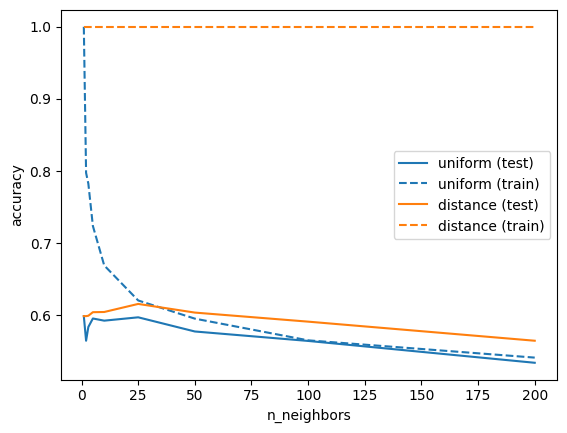

In [16]:
knn_raw_results = pd.DataFrame(knn_grid_raw.cv_results_)

for weight in ["uniform", "distance"]:
    subset = knn_raw_results[
        knn_raw_results["param_kneighborsclassifier__weights"] == weight
    ]

    line = plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_test_accuracy"],
        label=f"{weight} (test)"
    )[0]

    plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_train_accuracy"],
        "--",
        color=line.get_color(),
        label=f"{weight} (train)"
    )

plt.xlabel("n_neighbors")
plt.ylabel("accuracy")
plt.legend()
plt.show()

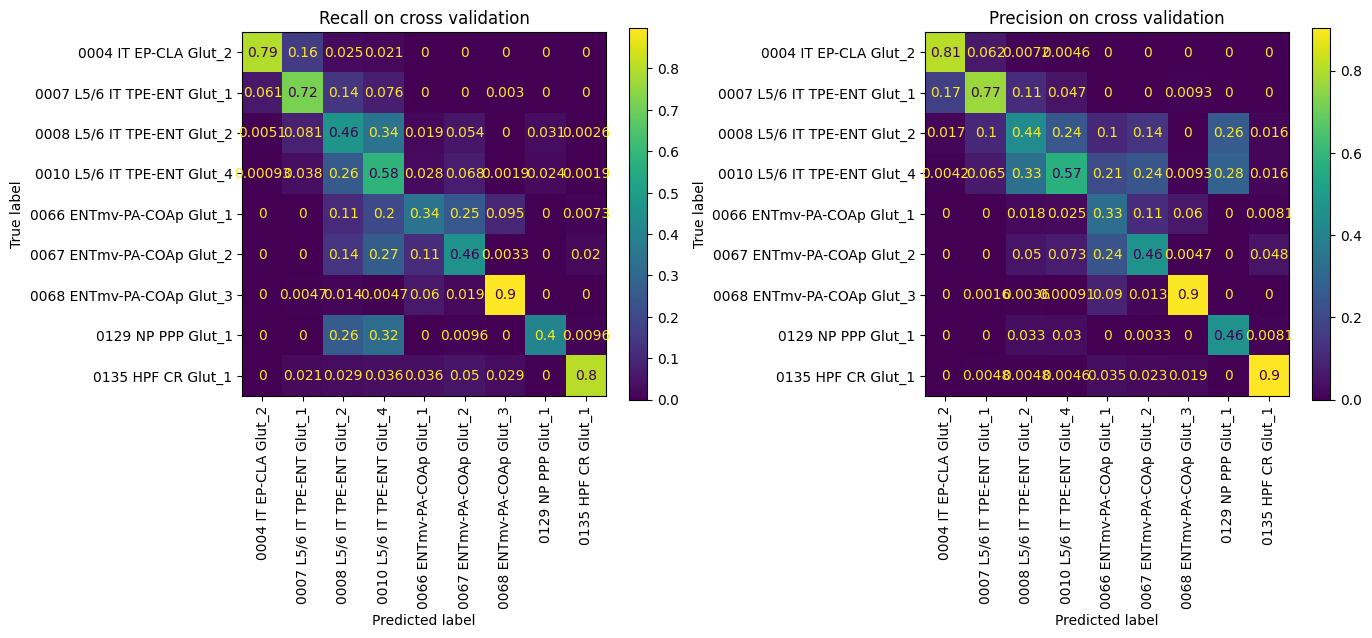

In [17]:
knn_raw_pred = cross_val_predict(
    knn_grid_raw.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_raw_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_raw_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [18]:
knn_raw_cr = classification_report(y_train, knn_raw_pred)
print(knn_raw_cr)


                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.81      0.79      0.80       242
0007 L5/6 IT TPE-ENT Glut_1       0.77      0.72      0.74       671
0008 L5/6 IT TPE-ENT Glut_2       0.44      0.46      0.45       779
0010 L5/6 IT TPE-ENT Glut_4       0.57      0.58      0.58      1077
  0066 ENTmv-PA-COAp Glut_1       0.33      0.34      0.33       137
  0067 ENTmv-PA-COAp Glut_2       0.46      0.46      0.46       301
  0068 ENTmv-PA-COAp Glut_3       0.90      0.90      0.90       215
         0129 NP PPP Glut_1       0.46      0.40      0.43       104
         0135 HPF CR Glut_1       0.90      0.80      0.85       140

                   accuracy                           0.60      3666
                  macro avg       0.63      0.61      0.62      3666
               weighted avg       0.60      0.60      0.60      3666



## Scaling

In [19]:
knn_pipe_scale = make_pipeline(
    ColumnTransformer([("scale", StandardScaler(),['x','y','z'])], 
                      remainder = 'passthrough'),
    KNeighborsClassifier()
)
param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 2, 5, 10, 20, 30, 40, 50, 60],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=4
)

knn_grid_scale = GridSearchCV(
    knn_pipe_scale,
    param_grid=param_grid,
    scoring=scoring,
    refit="f1_macro",   # chooses best model using this metric
    cv=cv,
    return_train_score=True
)

knn_grid_scale.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'kneighborsclassifier__n_neighbors': [1, 2, ...], 'kneighborsclassifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'balanced_accuracy': 'balanced_accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",Stratifie

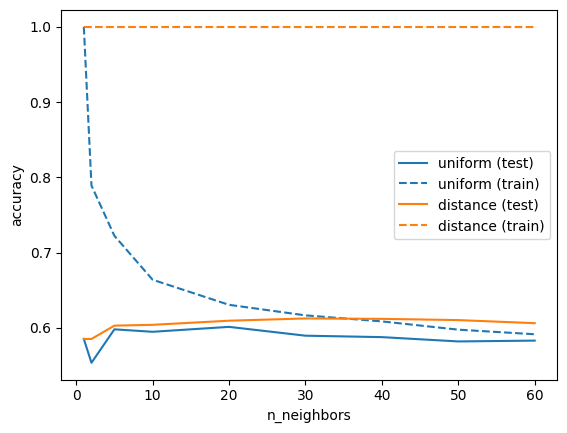

In [20]:
knn_scale_results = pd.DataFrame(knn_grid_scale.cv_results_)
for weight in ["uniform", "distance"]:
    subset = knn_scale_results[
        knn_scale_results["param_kneighborsclassifier__weights"] == weight
    ]

    line = plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_test_accuracy"],
        label=f"{weight} (test)"
    )[0]

    plt.plot(
        subset["param_kneighborsclassifier__n_neighbors"],
        subset["mean_train_accuracy"],
        "--",
        color=line.get_color(),
        label=f"{weight} (train)"
    )

plt.xlabel("n_neighbors")
plt.ylabel("accuracy")
plt.legend()
plt.show()

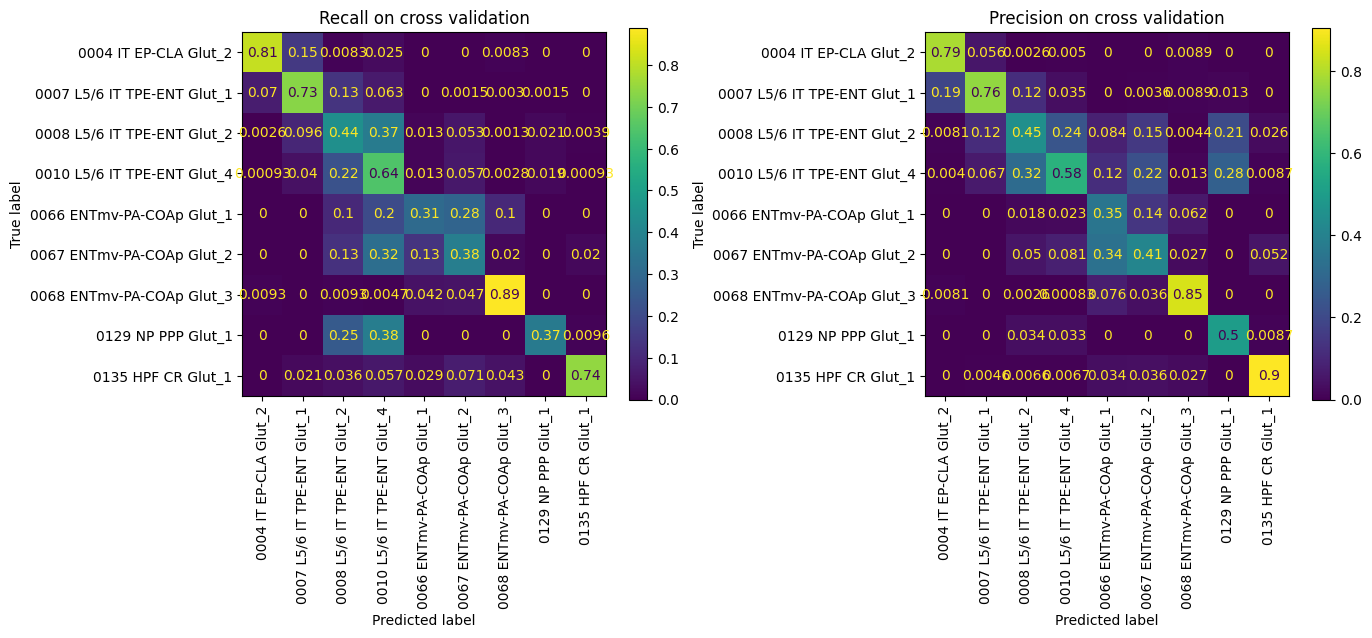

In [21]:
knn_scale_pred = cross_val_predict(
    knn_grid_scale.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_scale_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    knn_scale_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [22]:
knn_scale_cr = classification_report(y_train, knn_scale_pred)
print(knn_scale_cr)

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.79      0.81      0.80       242
0007 L5/6 IT TPE-ENT Glut_1       0.76      0.73      0.74       671
0008 L5/6 IT TPE-ENT Glut_2       0.45      0.44      0.45       779
0010 L5/6 IT TPE-ENT Glut_4       0.58      0.64      0.61      1077
  0066 ENTmv-PA-COAp Glut_1       0.35      0.31      0.33       137
  0067 ENTmv-PA-COAp Glut_2       0.41      0.38      0.40       301
  0068 ENTmv-PA-COAp Glut_3       0.85      0.89      0.87       215
         0129 NP PPP Glut_1       0.50      0.37      0.42       104
         0135 HPF CR Glut_1       0.90      0.74      0.82       140

                   accuracy                           0.60      3666
                  macro avg       0.62      0.59      0.60      3666
               weighted avg       0.60      0.60      0.60      3666



# Logistic Regression

In [23]:
logreg_pipe = make_pipeline(
    ColumnTransformer([("scale", StandardScaler(), ['x','y','z'])], remainder='passthrough'),
    LogisticRegression(
        max_iter=5000,
        solver="lbfgs"
    )
)

logreg_param_grid = {
    "logisticregression__C": np.logspace(-3, 3, 50)
}

logreg_grid = GridSearchCV(
    logreg_pipe,
    param_grid=logreg_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=4
)

logreg_grid.fit(X_train, y_train)

best_logreg = logreg_grid.best_estimator_
logreg_grid.best_params_

{'logisticregression__C': np.float64(59.636233165946365)}

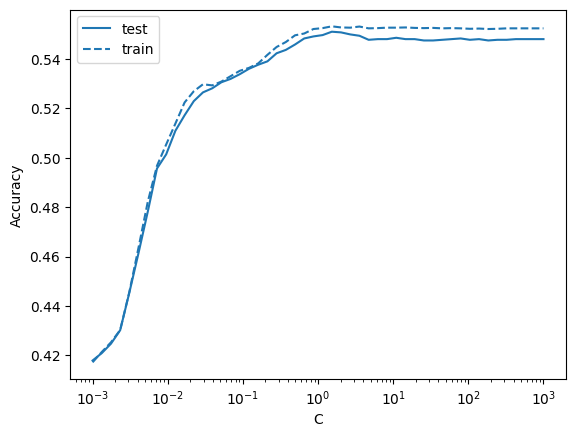

In [24]:
logreg_results = pd.DataFrame(logreg_grid.cv_results_)

line = plt.plot(
    logreg_results["param_logisticregression__C"],
    logreg_results["mean_test_accuracy"],
    label="test"
)[0]

plt.plot(
    logreg_results["param_logisticregression__C"],
    logreg_results["mean_train_accuracy"],
    "--",
    color=line.get_color(),
    label="train"
)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

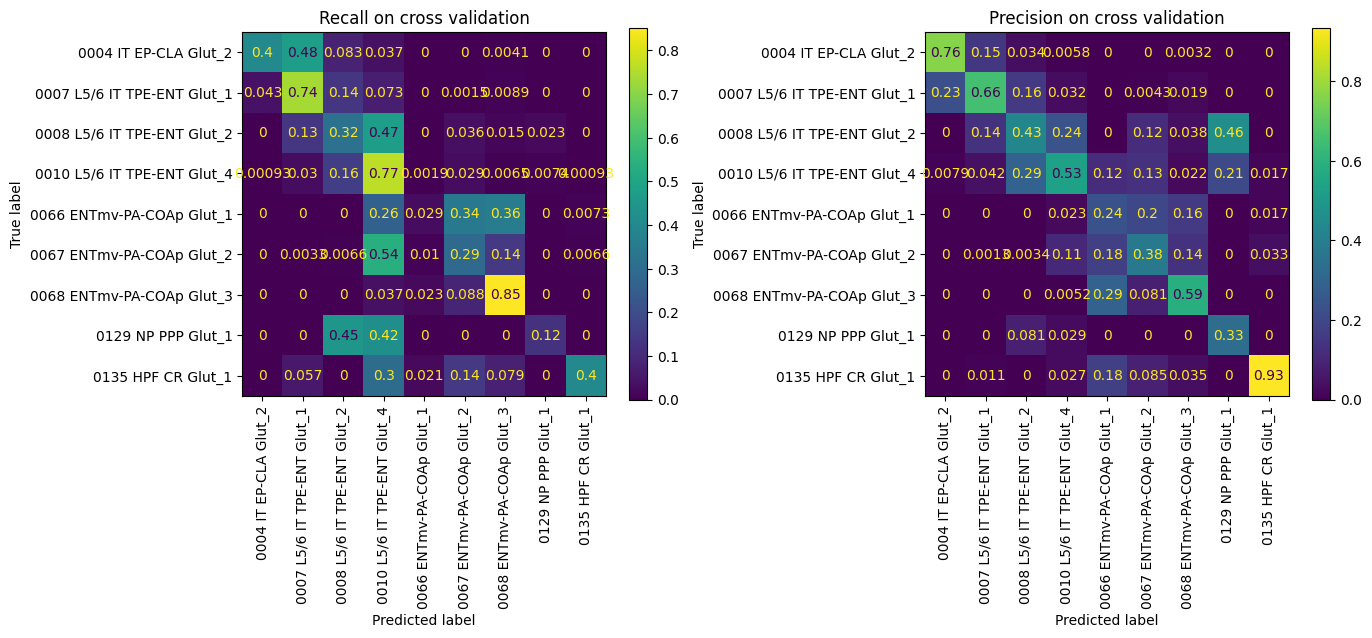

In [25]:
logreg_pred = cross_val_predict(
    logreg_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    logreg_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    logreg_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [26]:
logreg_cr = classification_report(y_train, logreg_pred)
print(logreg_cr)

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.76      0.40      0.53       242
0007 L5/6 IT TPE-ENT Glut_1       0.66      0.74      0.69       671
0008 L5/6 IT TPE-ENT Glut_2       0.43      0.32      0.37       779
0010 L5/6 IT TPE-ENT Glut_4       0.53      0.77      0.63      1077
  0066 ENTmv-PA-COAp Glut_1       0.24      0.03      0.05       137
  0067 ENTmv-PA-COAp Glut_2       0.38      0.29      0.33       301
  0068 ENTmv-PA-COAp Glut_3       0.59      0.85      0.69       215
         0129 NP PPP Glut_1       0.33      0.12      0.18       104
         0135 HPF CR Glut_1       0.93      0.40      0.56       140

                   accuracy                           0.55      3666
                  macro avg       0.54      0.44      0.45      3666
               weighted avg       0.54      0.55      0.52      3666



# SVM with RBF kernel

In [27]:
svm_pipe = make_pipeline(
    ColumnTransformer([("scale", StandardScaler(), ['x','y','z'])], remainder='passthrough'),
    SVC(kernel="rbf", class_weight='balanced')
)

svm_param_grid = {
    "svc__C": np.logspace(-4, 4, 20),
    "svc__gamma": np.logspace(-4, 4, 20)
}

svm_grid = GridSearchCV(
    svm_pipe,
    param_grid=svm_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_



In [28]:
svm_grid.best_params_

{'svc__C': np.float64(1438.44988828766),
 'svc__gamma': np.float64(4.281332398719396)}

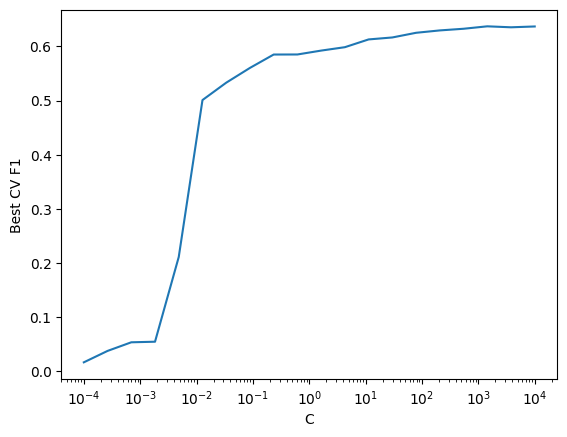

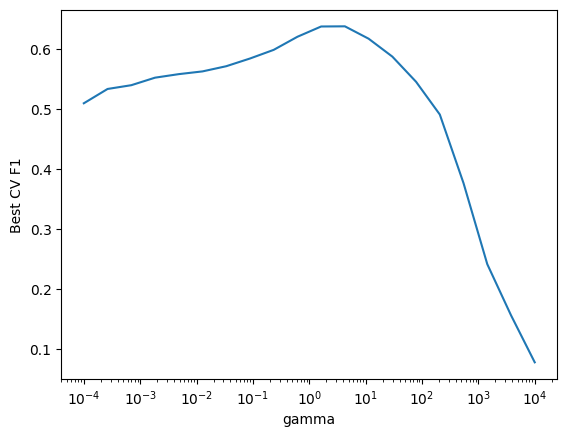

In [29]:
svm_results = pd.DataFrame(svm_grid.cv_results_)

best_by_C = (
    svm_results
    .groupby("param_svc__C")["mean_test_f1_macro"]
    .max()
)

plt.plot(best_by_C.index, best_by_C.values)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Best CV F1")
plt.show()

best_by_gamma = (
    svm_results
    .groupby("param_svc__gamma")["mean_test_f1_macro"]
    .max()
)

plt.plot(best_by_gamma.index, best_by_gamma.values)
plt.xscale("log")
plt.xlabel("gamma")
plt.ylabel("Best CV F1")
plt.show()

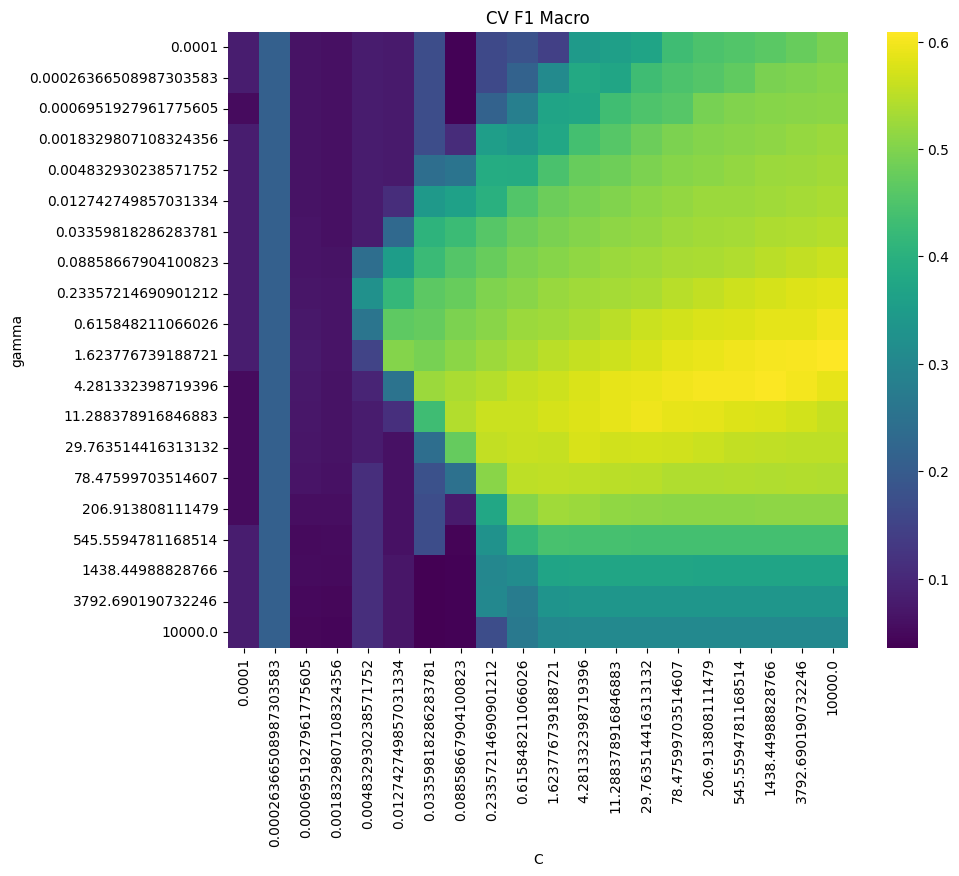

In [30]:
pivot = svm_results.pivot_table(
    values="mean_test_accuracy",
    index="param_svc__gamma",
    columns="param_svc__C"
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot,
    cmap="viridis"
)

plt.xlabel("C")
plt.ylabel("gamma")
plt.title("CV F1 Macro")
pivot.index = np.round(np.log10(pivot.index.astype(float)), 2)
pivot.columns = np.round(np.log10(pivot.columns.astype(float)), 2)
plt.show()

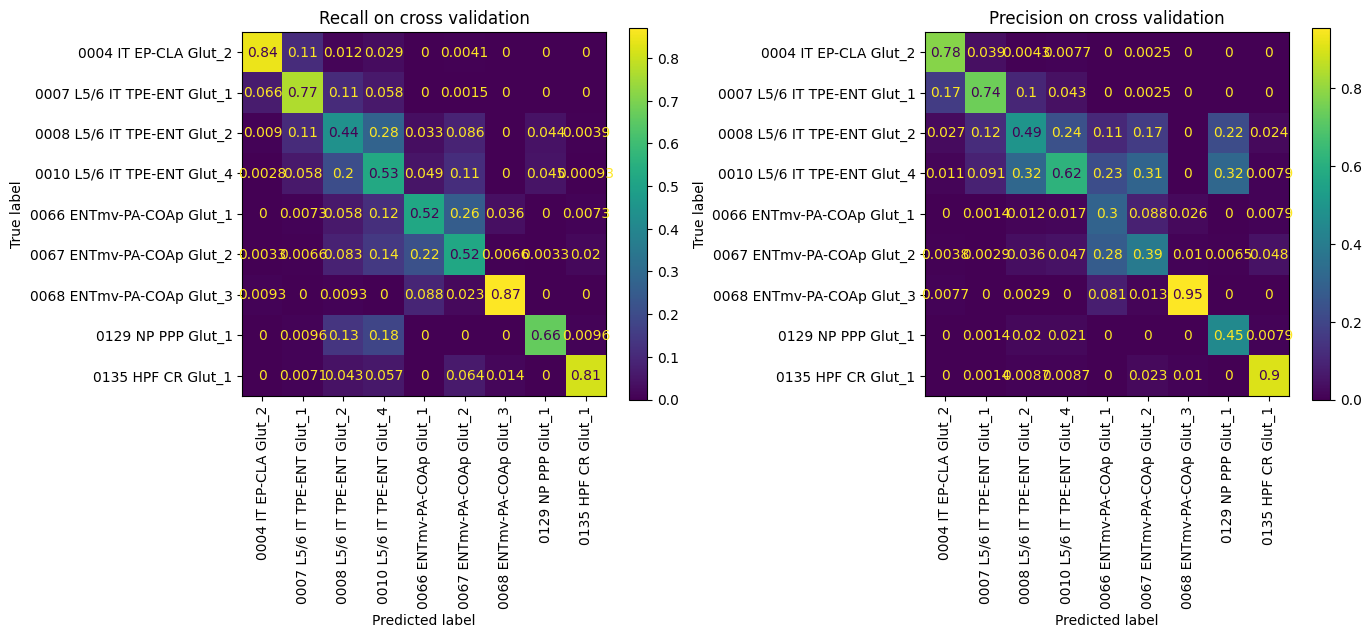

In [31]:
svm_pred = cross_val_predict(
    svm_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    svm_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    svm_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [32]:
svm_cr = classification_report(y_train, svm_pred)
print(svm_cr)

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.78      0.84      0.81       242
0007 L5/6 IT TPE-ENT Glut_1       0.74      0.77      0.76       671
0008 L5/6 IT TPE-ENT Glut_2       0.49      0.44      0.46       779
0010 L5/6 IT TPE-ENT Glut_4       0.62      0.53      0.57      1077
  0066 ENTmv-PA-COAp Glut_1       0.30      0.52      0.38       137
  0067 ENTmv-PA-COAp Glut_2       0.39      0.52      0.45       301
  0068 ENTmv-PA-COAp Glut_3       0.95      0.87      0.91       215
         0129 NP PPP Glut_1       0.45      0.66      0.54       104
         0135 HPF CR Glut_1       0.90      0.81      0.86       140

                   accuracy                           0.61      3666
                  macro avg       0.63      0.66      0.64      3666
               weighted avg       0.62      0.61      0.61      3666



# SVM with balanced weights

In [42]:
svm_bal_pipe = make_pipeline(
    ColumnTransformer([("scale", StandardScaler(), ['x','y','z'])], remainder='passthrough'),
    SVC(kernel="rbf", class_weight='balanced')
)

svm_param_grid = {
    "svc__C": np.logspace(-1, 5, 20),
    "svc__gamma": np.logspace(-3, 3, 10)
}

svm_bal_grid = GridSearchCV(
    svm_bal_pipe,
    param_grid=svm_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

svm_bal_grid.fit(X_train, y_train)

best_svm_bal = svm_bal_grid.best_estimator_



In [43]:
svm_bal_grid.best_params_

{'svc__C': np.float64(11288.378916846883),
 'svc__gamma': np.float64(2.154434690031882)}

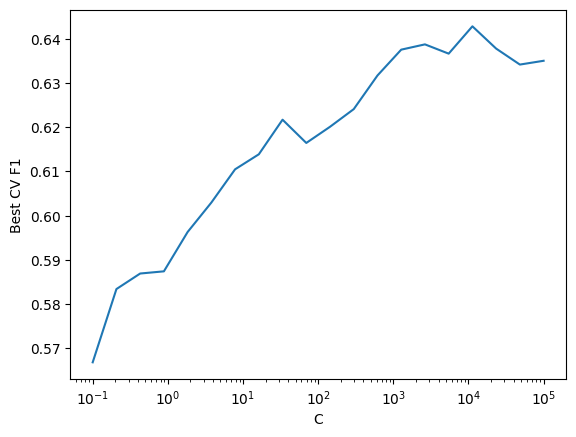

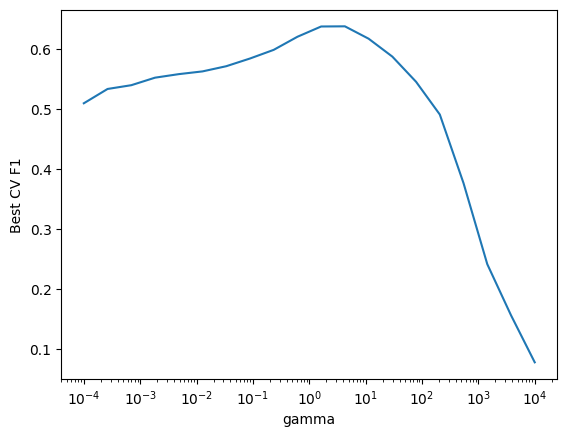

In [44]:
svm_bal_results = pd.DataFrame(svm_bal_grid.cv_results_)

best_by_C = (
    svm_bal_results
    .groupby("param_svc__C")["mean_test_f1_macro"]
    .max()
)

plt.plot(best_by_C.index, best_by_C.values)
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Best CV F1")
plt.show()

best_by_gamma = (
    svm_results
    .groupby("param_svc__gamma")["mean_test_f1_macro"]
    .max()
)

plt.plot(best_by_gamma.index, best_by_gamma.values)
plt.xscale("log")
plt.xlabel("gamma")
plt.ylabel("Best CV F1")
plt.show()

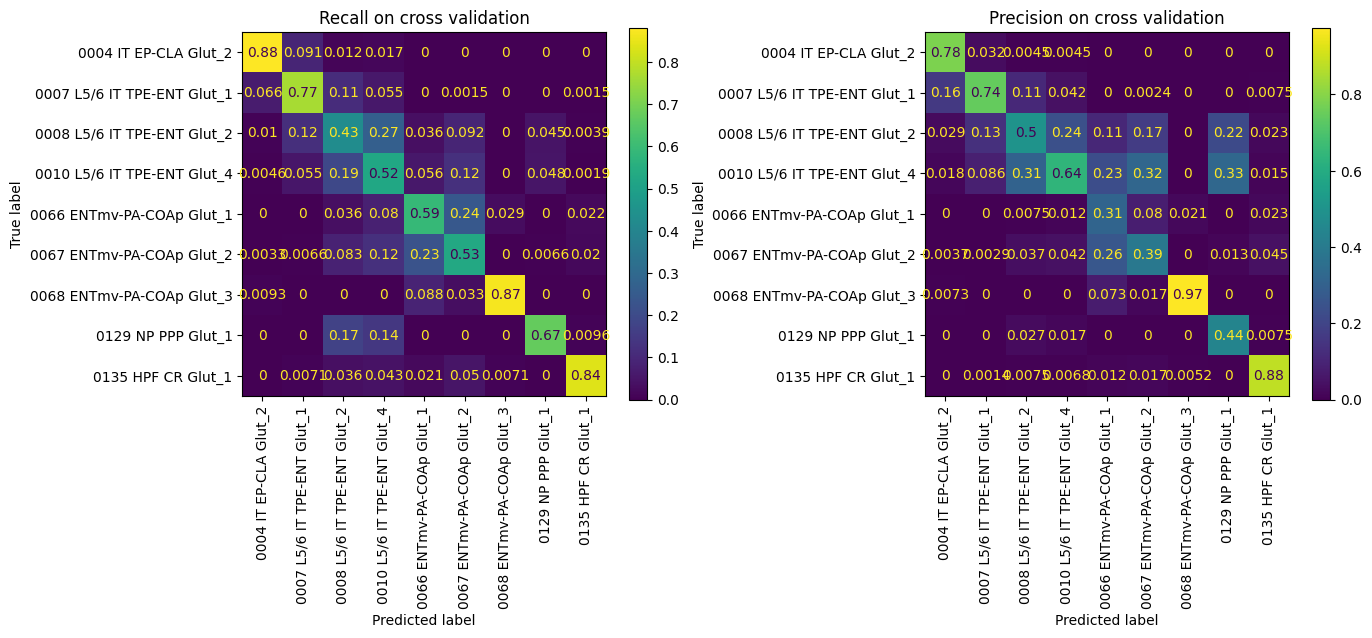

In [46]:
svm_bal_pred = cross_val_predict(
    svm_bal_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    svm_bal_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    svm_bal_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [47]:
svm_bal_cr = classification_report(y_train, svm_bal_pred)
print(svm_bal_cr)

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.78      0.88      0.83       242
0007 L5/6 IT TPE-ENT Glut_1       0.74      0.77      0.76       671
0008 L5/6 IT TPE-ENT Glut_2       0.50      0.43      0.46       779
0010 L5/6 IT TPE-ENT Glut_4       0.64      0.52      0.58      1077
  0066 ENTmv-PA-COAp Glut_1       0.31      0.59      0.41       137
  0067 ENTmv-PA-COAp Glut_2       0.39      0.53      0.45       301
  0068 ENTmv-PA-COAp Glut_3       0.97      0.87      0.92       215
         0129 NP PPP Glut_1       0.44      0.67      0.53       104
         0135 HPF CR Glut_1       0.88      0.84      0.86       140

                   accuracy                           0.61      3666
                  macro avg       0.63      0.68      0.64      3666
               weighted avg       0.63      0.61      0.61      3666



# Decision Tree

In [48]:
tree_pipe = Pipeline([
    ("tree", DecisionTreeClassifier(random_state=42))
])

tree_param_grid = {
    "tree__max_depth": [2, 3, 4, 5, 6, 10, 50, 100, None],
    "tree__min_samples_leaf": [1, 2, 5, 10, 20, 50, 100],
    "tree__criterion": ["gini", "entropy"]
}

tree_grid = GridSearchCV(
    tree_pipe,
    param_grid=tree_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

best_tree = tree_grid.best_estimator_

tree_grid.best_params_

{'tree__criterion': 'gini', 'tree__max_depth': 10, 'tree__min_samples_leaf': 5}

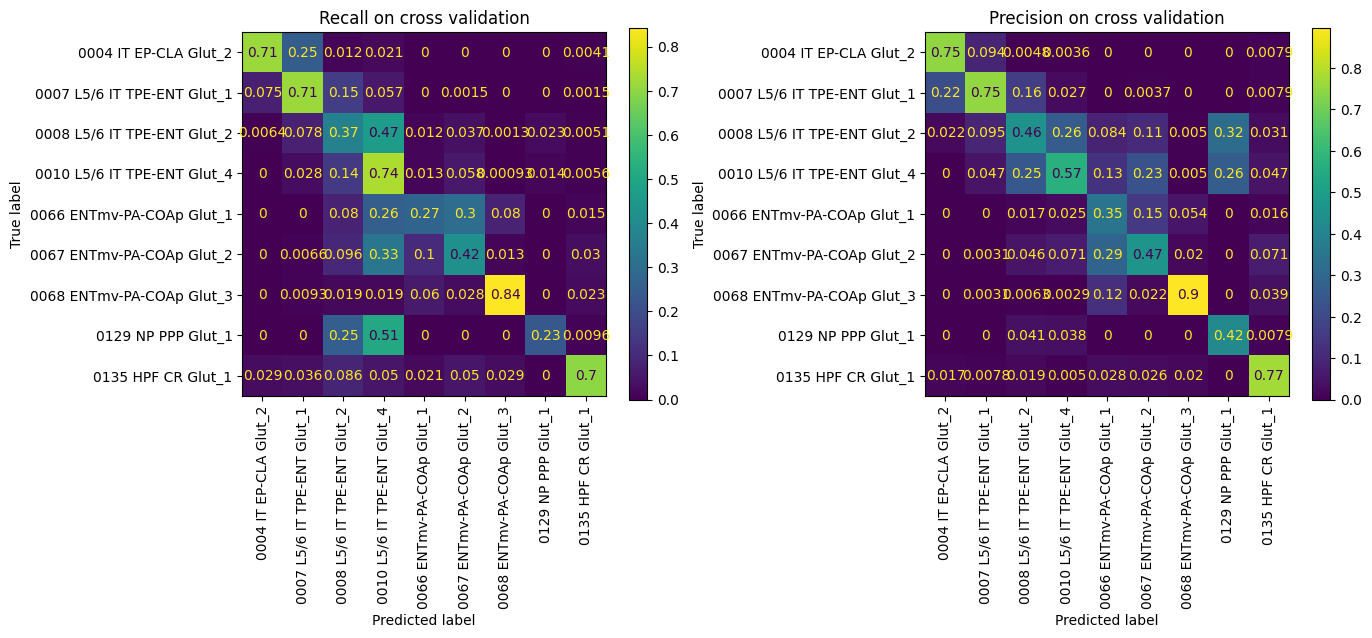

In [49]:
tree_pred = cross_val_predict(
    tree_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    tree_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    tree_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [50]:
svm_cr = classification_report(y_train, tree_pred)
print(svm_cr)

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.75      0.71      0.73       242
0007 L5/6 IT TPE-ENT Glut_1       0.75      0.71      0.73       671
0008 L5/6 IT TPE-ENT Glut_2       0.46      0.37      0.41       779
0010 L5/6 IT TPE-ENT Glut_4       0.57      0.74      0.64      1077
  0066 ENTmv-PA-COAp Glut_1       0.35      0.27      0.30       137
  0067 ENTmv-PA-COAp Glut_2       0.47      0.42      0.44       301
  0068 ENTmv-PA-COAp Glut_3       0.90      0.84      0.87       215
         0129 NP PPP Glut_1       0.42      0.23      0.30       104
         0135 HPF CR Glut_1       0.77      0.70      0.73       140

                   accuracy                           0.60      3666
                  macro avg       0.60      0.56      0.57      3666
               weighted avg       0.60      0.60      0.59      3666



In [51]:
# ============================================================
# 4. Random Forest
# ============================================================

rf_pipe = Pipeline([
    ("rf", RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    "rf__n_estimators": [1, 2, 3, 5, 10, 20],
    "rf__max_depth": [3, 5, 10, 20, 30, 40, 50, 75, 100, 200, None],
    "rf__min_samples_leaf": [1, 2, 5, 10, 20, 30, 40, 50],
    "rf__max_features": ["sqrt", None]
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

rf_grid.best_params_

{'rf__max_depth': 40,
 'rf__max_features': None,
 'rf__min_samples_leaf': 2,
 'rf__n_estimators': 20}

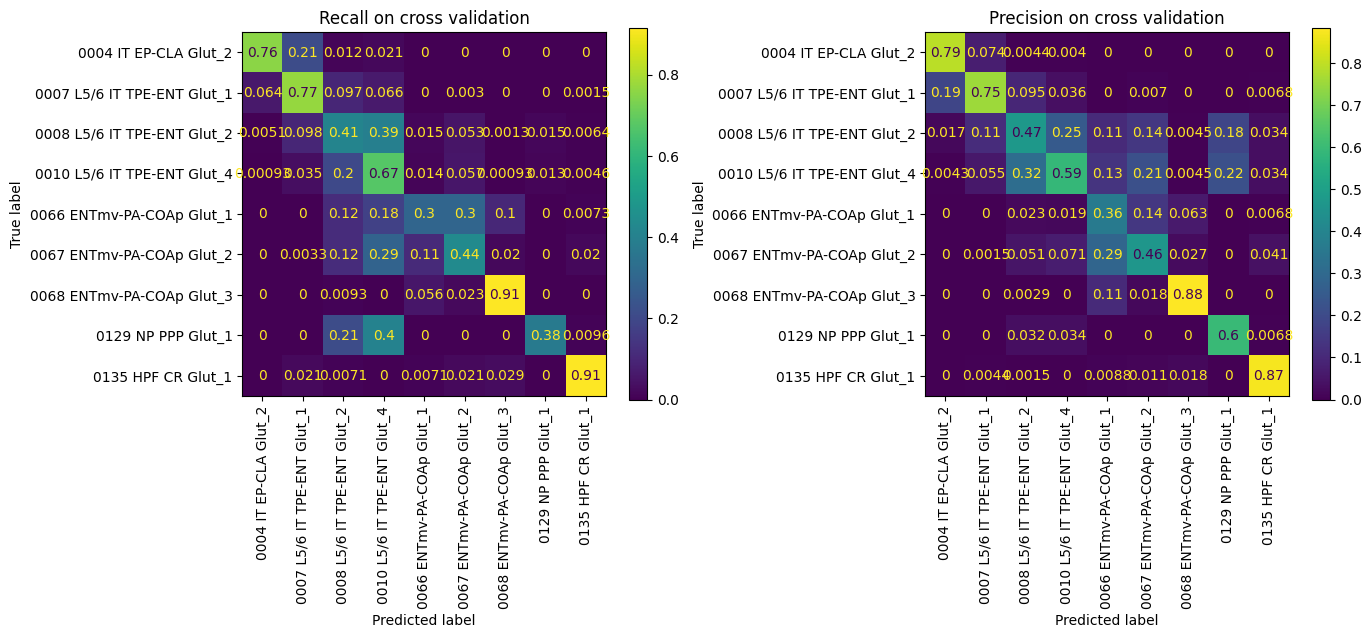

In [52]:
rf_pred = cross_val_predict(
    rf_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    rf_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    rf_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [53]:
rf_cr = classification_report(y_train, rf_pred)
print(rf_cr)

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.79      0.76      0.77       242
0007 L5/6 IT TPE-ENT Glut_1       0.75      0.77      0.76       671
0008 L5/6 IT TPE-ENT Glut_2       0.47      0.41      0.44       779
0010 L5/6 IT TPE-ENT Glut_4       0.59      0.67      0.63      1077
  0066 ENTmv-PA-COAp Glut_1       0.36      0.30      0.33       137
  0067 ENTmv-PA-COAp Glut_2       0.46      0.44      0.45       301
  0068 ENTmv-PA-COAp Glut_3       0.88      0.91      0.90       215
         0129 NP PPP Glut_1       0.60      0.38      0.46       104
         0135 HPF CR Glut_1       0.87      0.91      0.89       140

                   accuracy                           0.62      3666
                  macro avg       0.64      0.62      0.63      3666
               weighted avg       0.62      0.62      0.62      3666



In [54]:
# ============================================================
# 6. HistGradientBoostingClassifier
# ============================================================

hgb_pipe = Pipeline([
    ("hgb", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_grid = {
    "hgb__learning_rate": np.logspace(-3,1,10),
    "hgb__max_iter": np.linspace(1,100,10, dtype=int),
    "hgb__max_leaf_nodes": [2, 7, 15],
    "hgb__l2_regularization": np.linspace(0,1,10)
}

hgb_grid = GridSearchCV(
    hgb_pipe,
    param_grid=hgb_param_grid,
    scoring=scoring,
    refit="f1_macro",
    cv=cv,
    return_train_score=True,
    n_jobs=-1
)

hgb_grid.fit(X_train, y_train)

best_hgb = hgb_grid.best_estimator_

hgb_grid.best_params_

{'hgb__l2_regularization': np.float64(0.7777777777777777),
 'hgb__learning_rate': np.float64(0.1668100537200059),
 'hgb__max_iter': np.int64(34),
 'hgb__max_leaf_nodes': 15}

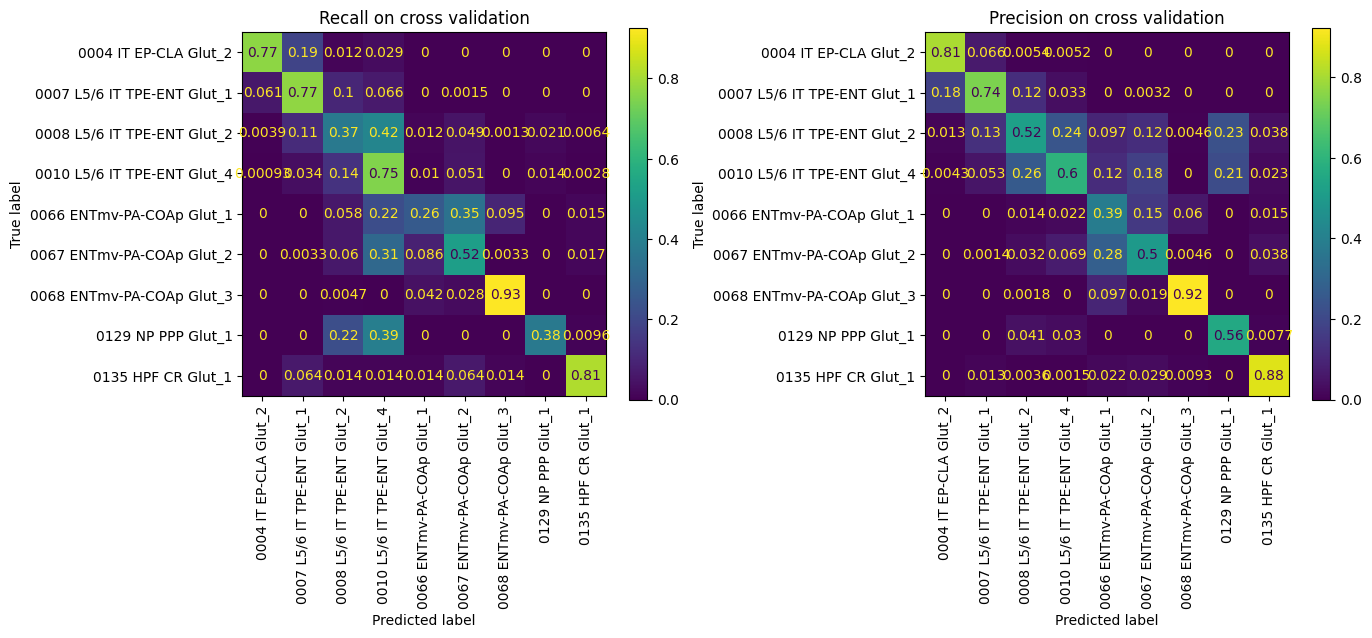

In [55]:
hgb_pred = cross_val_predict(
    hgb_grid.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    n_jobs=-1
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_train,
    hgb_pred,
    normalize="true",
    xticks_rotation=90,
    ax=axes[0]
)

axes[0].set_title("Recall on cross validation")

ConfusionMatrixDisplay.from_predictions(
    y_train,
    hgb_pred,
    normalize="pred",
    xticks_rotation=90,
    ax=axes[1]
)

axes[1].set_title("Precision on cross validation")

plt.tight_layout()
plt.show()

In [56]:
hgb_cr = classification_report(y_train, hgb_pred)
print(hgb_cr)

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.81      0.77      0.79       242
0007 L5/6 IT TPE-ENT Glut_1       0.74      0.77      0.76       671
0008 L5/6 IT TPE-ENT Glut_2       0.52      0.37      0.43       779
0010 L5/6 IT TPE-ENT Glut_4       0.60      0.75      0.67      1077
  0066 ENTmv-PA-COAp Glut_1       0.39      0.26      0.31       137
  0067 ENTmv-PA-COAp Glut_2       0.50      0.52      0.51       301
  0068 ENTmv-PA-COAp Glut_3       0.92      0.93      0.92       215
         0129 NP PPP Glut_1       0.56      0.38      0.45       104
         0135 HPF CR Glut_1       0.88      0.81      0.84       140

                   accuracy                           0.64      3666
                  macro avg       0.66      0.62      0.63      3666
               weighted avg       0.63      0.64      0.63      3666



In [57]:
summary_rows = []

for model_name, grid in [
    ("k-NN-raw", knn_grid_raw),
    ("k-NN-scale", knn_grid_scale),
    ("Logistic Regression", logreg_grid),
    ("Decision Tree", tree_grid),
    ("Random Forest", rf_grid),
    ("SVM RBF", svm_grid),
    ("HistGradientBoosting", hgb_grid)
]:
    best_idx = grid.best_index_

    summary_rows.append({
        "model": model_name,
        "best_params": grid.best_params_,
        "mean_cv_accuracy": grid.cv_results_["mean_test_accuracy"][best_idx],
        "mean_cv_balanced_accuracy": grid.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "mean_cv_f1_macro": grid.cv_results_["mean_test_f1_macro"][best_idx],
        "mean_cv_recall_macro": grid.cv_results_["mean_test_recall_macro"][best_idx],
        "mean_cv_precision_macro": grid.cv_results_["mean_test_precision_macro"][best_idx],
    })

model_summary = pd.DataFrame(summary_rows)

model_summary.sort_values(
    "mean_cv_f1_macro",
    ascending=False
)

,model,best_params,mean_cv_accuracy,mean_cv_balanced_accuracy,mean_cv_f1_macro,mean_cv_recall_macro,mean_cv_precision_macro
5,SVM RBF,"{'svc__C': 1438.44988828766, 'svc__gamma': 4.2...",0.606651,0.662097,0.637123,0.662097,0.629108
6,HistGradientBoosting,"{'hgb__l2_regularization': 0.7777777777777777,...",0.640204,0.617886,0.630377,0.617886,0.657267
4,Random Forest,"{'rf__max_depth': 40, 'rf__max_features': None...",0.622473,0.616713,0.624850,0.616713,0.643242
0,k-NN-raw,"{'kneighborsclassifier__n_neighbors': 1, 'knei...",0.599015,0.607128,0.614480,0.607128,0.626287
1,k-NN-scale,"{'kneighborsclassifier__n_neighbors': 5, 'knei...",0.602832,0.589550,0.602191,0.589550,0.622025
3,Decision Tree,"{'tree__criterion': 'gini', 'tree__max_depth':...",0.600652,0.555693,0.571109,0.555693,0.603254
2,Logistic Regression,{'logisticregression__C': 59.636233165946365},0.548007,0.435776,0.446188,0.435776,0.550850


# Estimating Generalisation error on test set


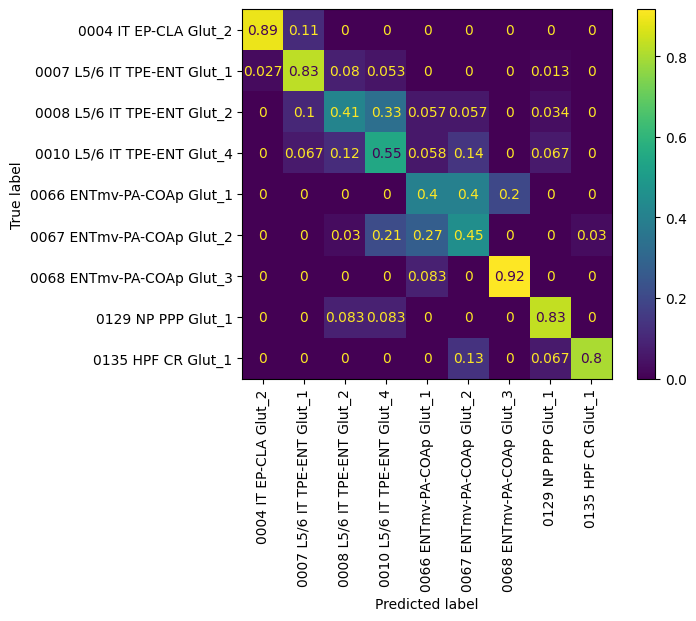

In [64]:
best_svm_test = svm_bal_grid.best_estimator_

test_pred = best_svm_test.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    normalize="true",
    xticks_rotation=90)

plt.savefig(
    "Figures/appendix_confusionmatrix.png",
    bbox_inches="tight",
    facecolor="white"
)
plt.show()

In [59]:
print(classification_report(y_test, test_pred))

                             precision    recall  f1-score   support

      0004 IT EP-CLA Glut_2       0.96      0.93      0.94        27
0007 L5/6 IT TPE-ENT Glut_1       0.78      0.81      0.80        75
0008 L5/6 IT TPE-ENT Glut_2       0.56      0.40      0.47        87
0010 L5/6 IT TPE-ENT Glut_4       0.60      0.52      0.56       120
  0066 ENTmv-PA-COAp Glut_1       0.19      0.40      0.26        15
  0067 ENTmv-PA-COAp Glut_2       0.30      0.39      0.34        33
  0068 ENTmv-PA-COAp Glut_3       0.88      0.96      0.92        24
         0129 NP PPP Glut_1       0.38      0.75      0.50        12
         0135 HPF CR Glut_1       0.92      0.80      0.86        15

                   accuracy                           0.60       408
                  macro avg       0.62      0.66      0.63       408
               weighted avg       0.63      0.60      0.61       408



In [60]:
final_svm = clone(best_svm)

final_svm.set_params(svc__probability=True)

final_svm.fit(X, y)

final_svm.named_steps

{'columntransformer': ColumnTransformer(remainder='passthrough',
                   transformers=[('scale', StandardScaler(), ['x', 'y', 'z'])]),
 'svc': SVC(C=np.float64(1438.44988828766), class_weight='balanced',
     gamma=np.float64(4.281332398719396), probability=True)}

In [61]:
joblib.dump(final_svm, "Models/best_svm_9supertypes.pkl")

['Models/best_svm_9supertypes.pkl']